In [1]:
# imports
import ast
import matplotlib
#%matplotlib ipympl
%matplotlib inline
import numpy as np
import os
import pandas as pd
import re
import seaborn as sns
import subprocess
import textwrap
import string
import sys

from collections import Counter, defaultdict, OrderedDict
from datetime import datetime
from file_read_backwards import FileReadBackwards
from glob import glob
from itertools import combinations, product
from matplotlib import pyplot as plt
from os.path import expanduser, exists, isdir

# from scipy.stats import linregress, ttest_ind_from_stats, theilslopes
# from scipy.stats.mstats import gmean
# from scipy.optimize import curve_fit

from sentropy import sentropy
from polyleven import levenshtein

# from sklearn.linear_model import LinearRegression
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA, FastICA
# from sklearn.metrics import mean_squared_error, r2_score
# from sklearn.model_selection import train_test_split
# from sklearn.svm import NuSVR, SVR # SVR in principle has lower error; NuSVR in principle has the simpler model; in practice these are the same
# from subprocess import call

from tqdm import tqdm
from time import time
from urllib.request import urlopen

plt.ion()

colors = OrderedDict([ # ~color brewer 9 color palette
    ("red", "#d53e4f"),
    ("dark orange", "#f46d43"),
    ("light orange", "#fdae61"),
    ("dark yellow", "#fee08b"),
    ("light yellow", "#ffffbf"),
    ("yellow green", "#e6f598"),
    ("light green", "#abdda4"),
    ("blue green", "#66c2a5"),
    ("blue", "#3288bd"),
    # ("gray", "#cccccc"),
    ("purple", "#8F90C6"),
    ])

In [2]:
flu_subsample_files = ['Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960382_hIgG_annotated_1e5_QZEiL.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960346_hIgG_annotated_1e5_hf2gQ.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960347_hIgG_annotated_1e5_mtM8k.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960352_hIgG_annotated_1e5_8xrND.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960353_hIgG_annotated_1e5_8OBmW.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960332_hIgG_annotated_1e5_dPKLV.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960338_hIgG_annotated_1e5_LqzW7.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960340_hIgG_annotated_1e5_T7xKf.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960380_hIgG_annotated_1e5_mgQeQ.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960367_hIgG_annotated_1e5_7M4uw.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960334_hIgG_annotated_1e5_zsTwF.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960337_hIgG_annotated_1e5_Dg9wZ.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960335_hIgG_annotated_1e5_OZTMk.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960331_hIgG_annotated_1e5_CMo9y.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960343_hIgG_annotated_1e5_kxaDu.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960349_hIgG_annotated_1e5_S9X98.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960358_hIgG_annotated_1e5_gbKPE.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960374_hIgG_annotated_1e5_6vSDo.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960365_hIgG_annotated_1e5_wXv2l.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960385_hIgG_annotated_1e5_lt2Rx.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960355_hIgG_annotated_1e5_PIzNn.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960376_hIgG_annotated_1e5_Qmazr.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960341_hIgG_annotated_1e5_OwKmW.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960350_hIgG_annotated_1e5_FsmnV.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960379_hIgG_annotated_1e5_n564v.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960364_hIgG_annotated_1e5_Qynfk.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960326_hIgG_annotated_1e5_Ocokl.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960378_hIgG_annotated_1e5_mTtlk.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960361_hIgG_annotated_1e5_6ZkEL.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960344_hIgG_annotated_1e5_stH41.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960328_hIgG_annotated_1e5_5xZQp.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960370_hIgG_annotated_1e5_f572X.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960368_hIgG_annotated_1e5_StTYj.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960371_hIgG_annotated_1e5_yo7q5.txt',
 'Flu_repertoire_subsamples_for_figs_4ab/recon_input_SRR960372_hIgG_annotated_1e5_lKnNQ.txt']

In [3]:
d0_igg_TIV_srrs = ['SRR960326', 'SRR960332', 'SRR960335', 'SRR960338', 'SRR960341', 'SRR960344', 'SRR960347',\
  'SRR960350', 'SRR960353', 'SRR960365', 'SRR960368', 'SRR960371', 'SRR960372', 'SRR960376', 'SRR960380', 'SRR960379']

d7_igg_TIV_srrs = ['SRR960328', 'SRR960334', 'SRR960337', 'SRR960340', 'SRR960343', 'SRR960346', 'SRR960349',\
  'SRR960352', 'SRR960355', 'SRR960367', 'SRR960370', 'SRR960374', 'SRR960378', 'SRR960382']

# Computing similarity-sensitive alpha diversities with sentropy

In [4]:
def similarity_function(species_i, species_j):
    return 0.3**levenshtein(species_i, species_j)

In [5]:
# Sanity check
assert(similarity_function("CARVV", "CARRW") == 0.09) # expect 0.3**2 = 0.09

In [6]:
SRR_alpha_subsample_hash = {}
for infile_subsample in tqdm(flu_subsample_files):
    # now = time()
    srr = infile_subsample.split("/")[-1].split("_")[2]
    seqs_subsample = []
    nos_subsample = []
    for line in open(infile_subsample, "r"):
        seq, no = line.strip().split()
        no = int(no)
        seqs_subsample.append(seq)
        nos_subsample.append(no)
    nos_subsample = np.array(nos_subsample)
    val = sentropy(
        nos_subsample,
        similarity=similarity_function,
        sfargs=np.array(seqs_subsample),
        chunk_size=200,
        parallelize=True,
        symmetric=True,
        q=0,
        # backend="torch",
        # device='mps'
    )
    SRR_alpha_subsample_hash[srr] = val

  0%|                                                    | 0/35 [00:00<?, ?it/s]2026-01-01 15:11:14,147	INFO worker.py:2012 -- Started a local Ray instance.
/Users/arnaoutlab/Desktop/sentropy/sentropy-venv/lib/python3.11/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
 29%|████████████▎                              | 10/35 [00:33<01:06,  2.65s/it][2026-01-01 15:11:47,706 E 26158 11930500] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(weighted_similarity_chunk_symmetric pid=26183) [2026-01-01 15:11:47,797 E 26183 11930798] core_worker_process.cc:825: Fail

In [7]:
SRR_alpha_subsample_hash, len(SRR_alpha_subsample_hash)

({'SRR960382': 7472.229900837759,
  'SRR960346': 4442.405371155911,
  'SRR960347': 13777.507348577394,
  'SRR960352': 5360.930728290507,
  'SRR960353': 7236.4489989226895,
  'SRR960332': 6323.215731822097,
  'SRR960338': 5550.21353075223,
  'SRR960340': 4503.928270020452,
  'SRR960380': 7621.758700125913,
  'SRR960367': 3795.872286503678,
  'SRR960334': 3956.8279696490918,
  'SRR960337': 8984.941125132533,
  'SRR960335': 7528.276473063496,
  'SRR960331': 4298.5707143251,
  'SRR960343': 10136.982822048765,
  'SRR960349': 4524.793135130546,
  'SRR960358': 4844.636711837327,
  'SRR960374': 5494.95198523219,
  'SRR960365': 5221.628802598342,
  'SRR960385': 3782.5612189369563,
  'SRR960355': 4617.179306936843,
  'SRR960376': 6494.276136994273,
  'SRR960341': 8808.57910665506,
  'SRR960350': 6965.99512807553,
  'SRR960379': 7751.972429653645,
  'SRR960364': 2693.32265194871,
  'SRR960326': 8312.33050819896,
  'SRR960378': 2852.6217732480072,
  'SRR960361': 2826.5057330933746,
  'SRR960344': 

In [8]:
day0_TIV_vaccine_SRR_0DZs = []
day7_TIV_vaccine_SRR_0DZs = []
for srr in d0_igg_TIV_srrs:
    value = SRR_alpha_subsample_hash[srr]      # note change to the above
    day0_TIV_vaccine_SRR_0DZs.append(value)
for srr in d7_igg_TIV_srrs:
    value = SRR_alpha_subsample_hash[srr]         # ditto
    day7_TIV_vaccine_SRR_0DZs.append(value)
day0_TIV_vaccine_SRR_0DZs = np.array(day0_TIV_vaccine_SRR_0DZs).flatten()
day7_TIV_vaccine_SRR_0DZs = np.array(day7_TIV_vaccine_SRR_0DZs).flatten()

In [9]:
day7_TIV_vaccine_SRR_0DZs = np.insert(day7_TIV_vaccine_SRR_0DZs, -1, day7_TIV_vaccine_SRR_0DZs[-1])    # because there are two SRRs for d0 for this person, duplicating a value for d7 makes sure d0 and d7 are paired
day7_TIV_vaccine_SRR_0DZs = np.insert(day7_TIV_vaccine_SRR_0DZs, 12, day7_TIV_vaccine_SRR_0DZs[11])    # ditto

In [10]:
day0_TIV_vaccine_SRR_0DZs, len(day0_TIV_vaccine_SRR_0DZs)

(array([ 8312.3305082 ,  6323.21573182,  7528.27647306,  5550.21353075,
         8808.57910666, 10502.63301813, 13777.50734858,  6965.99512808,
         7236.44899892,  5221.6288026 ,  5700.56979392,  3010.77011659,
         5017.72256328,  6494.27613699,  7621.75870013,  7751.97242965]),
 16)

In [11]:
day7_TIV_vaccine_SRR_0DZs, len(day7_TIV_vaccine_SRR_0DZs)

(array([ 5535.34738847,  3956.82796965,  8984.94112513,  4503.92827002,
        10136.98282205,  4442.40537116,  4524.79313513,  5360.93072829,
         4617.17930694,  3795.8722865 ,  4953.91905503,  5494.95198523,
         5494.95198523,  2852.62177325,  7472.22990084,  7472.22990084]),
 16)

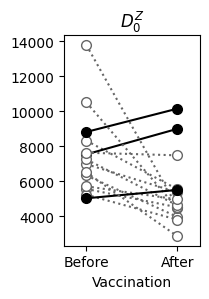

In [12]:
plt.figure(figsize=(2.2,3.1))
for i, (y1, y2) in enumerate(zip(day0_TIV_vaccine_SRR_0DZs, day7_TIV_vaccine_SRR_0DZs)):
    # leave out the duplicates
    if i in (11, 15): continue
    if y2 > y1: 
        ls = "-"
        markerfacecolor="black"
        markeredgecolor="black"
        color="black"
    else:
        ls=":"
        markerfacecolor="white"
        markeredgecolor="#666"
        color="#666"
    plt.plot(
        [0, 1], [y1, y2], 
        marker="o", 
        ls=ls,
        markerfacecolor=markerfacecolor, 
        markeredgecolor=markeredgecolor,
        c=color,
        markersize=7,
        )
plt.xlim(-0.25, 1.25)
ax = plt.gca()
xticklabels = ["Before", "After"]
ax.set_xticks([0, 1])
ax.set_xticklabels(xticklabels)
plt.xlabel("Vaccination")
plt.title(r"$D_0^Z$")
plt.tight_layout()
plt.show()

# Computing similarity-insensitive alpha diversities with recon 

In [16]:
error_bars_file = "Flu_repertoire_subsamples_for_figs_4ab/error_bar_parameters.txt"

srr_recon_D0_hash = {}
for infile in tqdm(flu_subsample_files):
    out1 = infile.replace("recon_input", "reconstructed")
    out2 = infile.replace("recon_input", "recon_output")
    reconstruction_cmd = f'Recon/recon.py -R -o {out1} {infile}'
    subprocess.check_output(reconstruction_cmd, shell=True)
    get_D_numbers_cmd = f'Recon/recon.py -D -Q 0 -b {error_bars_file} -o {out2} {out1}'
    # print(get_D_numbers_cmd)
    subprocess.check_output(get_D_numbers_cmd, shell=True)
    sample_name, results = open(out2, "r").readlines()[-1].split("\t", 1)
    obs_0D, est_0D, est_0D_lower, est_0D_upper = [float(i) for i in results.strip().split()]
    srr = sample_name.split("/")[-1].split("_")[1]
    srr_recon_D0_hash[srr] = (est_0D, est_0D_lower, est_0D_upper)

  0%|                                                    | 0/35 [00:00<?, ?it/s]/Users/arnaoutlab/.pyenv/versions/3.11.13/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
  3%|█▎                                          | 1/35 [00:02<01:11,  2.09s/it]/Users/arnaoutlab/.pyenv/versions/3.11.13/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
  6%|██▌                                         | 2/35 [00:03<00:57,  1.74s/it]/Users/arnaoutlab/.pyenv/versions/3.11.13/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
  9%|███▊                                        | 3/35 [00:04<00:46,  1.44s/it]/Users/arnaoutlab/.pyenv/versions/3.11.13/lib/python3.11/site-packages/scipy/opt

In [19]:
srr_recon_D0_hash

{'SRR960382': (43942.97795466889, 29573.62416349216, 80037.24788528083),
 'SRR960346': (34200.687116364505, 24761.2974722479, 57530.412227295616),
 'SRR960347': (81775.08397868468, 61903.738571864305, 140715.71873759813),
 'SRR960352': (26822.908775386422, 23818.742992543142, 31597.590391511898),
 'SRR960353': (42470.73996921779, 36524.8363735273, 54736.08581277604),
 'SRR960332': (25308.16908976235, 20347.767948168927, 37401.56633336129),
 'SRR960338': (21423.631694769363, 17481.6834629318, 32597.14394408168),
 'SRR960340': (30161.150423245697, 27175.196531344372, 35100.88331726403),
 'SRR960380': (49509.23335916713, 41587.756021700385, 67832.95709187507),
 'SRR960367': (26760.819869934217, 24218.541982290466, 30572.459782960475),
 'SRR960334': (24536.660693861497, 19114.05868051811, 39428.656910129735),
 'SRR960337': (52452.75125367624, 43640.68904305863, 73785.15930194336),
 'SRR960335': (41190.15861544957, 35505.91672651753, 53127.544388046794),
 'SRR960331': (32997.12443301111, 23

In [25]:
day0_TIV_vaccine_SRR_0Ds_w_recon = []
day7_TIV_vaccine_SRR_0Ds_w_recon = []
for srr in d0_igg_TIV_srrs:
    value = srr_recon_D0_hash[srr][0]
    day0_TIV_vaccine_SRR_0Ds_w_recon.append(value)
for srr in d7_igg_TIV_srrs:
    value = srr_recon_D0_hash[srr][0]
    day7_TIV_vaccine_SRR_0Ds_w_recon.append(value)
    
day0_TIV_vaccine_SRR_0Ds_w_recon = np.array(day0_TIV_vaccine_SRR_0Ds_w_recon).flatten()
day7_TIV_vaccine_SRR_0Ds_w_recon = np.array(day7_TIV_vaccine_SRR_0Ds_w_recon).flatten()

In [32]:
day7_TIV_vaccine_SRR_0Ds_w_recon = np.insert(day7_TIV_vaccine_SRR_0Ds_w_recon, -1, day7_TIV_vaccine_SRR_0Ds_w_recon[-1])    # because there are two SRRs for d0 for this person, duplicating a value for d7 makes sure d0 and d7 are paired
day7_TIV_vaccine_SRR_0Ds_w_recon = np.insert(day7_TIV_vaccine_SRR_0Ds_w_recon, 12, day7_TIV_vaccine_SRR_0Ds_w_recon[11])    # ditto

In [33]:
day0_TIV_vaccine_SRR_0Ds_w_recon, len(day0_TIV_vaccine_SRR_0Ds_w_recon)

(array([42072.91934553, 25308.16908976, 41190.15861545, 21423.63169477,
        77241.12828004, 38144.39915597, 81775.08397868, 34354.79588864,
        42470.73996922, 23944.41742766, 17009.78030734,  9239.8931392 ,
        27723.77481383, 19733.3599202 , 49509.23335917, 40911.21773332]),
 16)

In [34]:
day7_TIV_vaccine_SRR_0Ds_w_recon, len(day7_TIV_vaccine_SRR_0Ds_w_recon)

(array([42127.56475816, 24536.66069386, 52452.75125368, 30161.15042325,
        65852.22299606, 34200.68711636, 42196.91514843, 26822.90877539,
        35151.00603275, 26760.81986993, 24881.10587936, 45735.94196505,
        45735.94196505, 23374.90036085, 43942.97795467, 43942.97795467]),
 16)

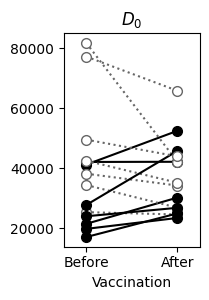

In [48]:
plt.figure(figsize=(2.2,3.1))
for i, (y1, y2) in enumerate(zip(day0_TIV_vaccine_SRR_0Ds_w_recon, day7_TIV_vaccine_SRR_0Ds_w_recon)):
    # leave out the duplicates
    if i in (11, 15): continue
    if y2 > y1: 
        ls = "-"
        markerfacecolor="black"
        markeredgecolor="black"
        color="black"
    else:
        ls=":"
        markerfacecolor="white"
        markeredgecolor="#666"
        color="#666"
    plt.plot(
        [0, 1], [y1, y2], 
        marker="o", 
        ls=ls,
        markerfacecolor=markerfacecolor, 
        markeredgecolor=markeredgecolor,
        c=color,
        markersize=7,
        )
plt.xlim(-0.25, 1.25)
ax = plt.gca()
xticklabels = ["Before", "After"]
ax.set_xticks([0, 1])
ax.set_xticklabels(xticklabels)
plt.xlabel("Vaccination")
plt.title(r"$D_0$")
plt.tight_layout()
plt.show()

# Plotting

deltas.T.shape: (14, 2)


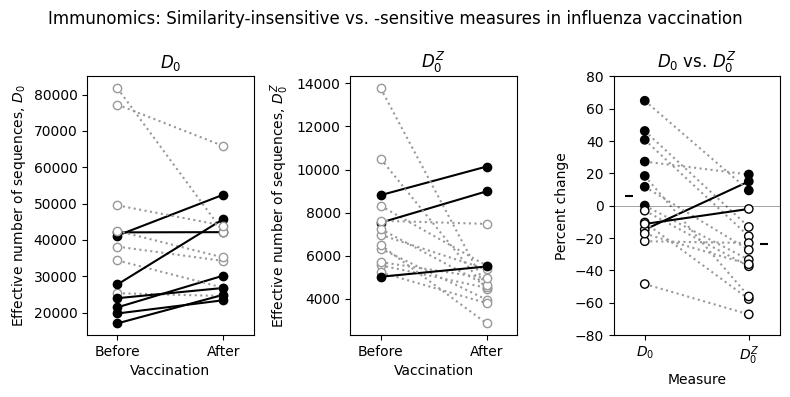

In [53]:
datas  = (day0_TIV_vaccine_SRR_0Ds_w_recon, day7_TIV_vaccine_SRR_0Ds_w_recon), (day0_TIV_vaccine_SRR_0DZs, day7_TIV_vaccine_SRR_0DZs)
names  = ("D", "DZ")
labels = ("$D_0$", "$D^Z_0$")
up_colors = ("black", "black")
down_colors = ("#999", "#999")
up_facecolors = ("black", "black")
down_facecolors = ("white", "white")
up_alpha = 1.
down_alpha = 1.

deltas = []
colors = []

fig, axs = plt.subplots(ncols=3, figsize=(8,4))

for i, (data, name, label) in enumerate(zip(datas, names, labels)):
    ax = axs[i]
    delta = []; c = []
    for j, y in enumerate(zip(data[0], data[1])):
        if j in (11, 15): continue #remove duplicates
        delta.append((y[1] - y[0])/y[0])
        if y[1] > y[0]: 
            facecolor = up_facecolors[i]
            edgecolor = up_colors[i]
            linecolor = edgecolor
            ls        = "-"
            alpha = up_alpha
            c.append(up_facecolors[i])
        else:
            facecolor = down_facecolors[i]
            edgecolor = down_colors[i]
            linecolor = edgecolor
            ls        = ":"
            alpha = down_alpha
            c.append(down_facecolors[i])
        ax.plot([0, 7], list(y), color=linecolor, ls=ls, alpha=alpha)
        ax.scatter([0, 7], list(y), marker="o", facecolors=facecolor, 
                    edgecolors=edgecolor, zorder=1000, alpha=alpha)
    deltas.append(delta)
    colors.append(c)
    ax.set_xticks([0, 7])
    ax.set_xticklabels(["Before", "After"])
    ax.set_xlim(-2, 9)
    ax.set_xlabel("Vaccination")
    ax.set_ylabel(f"Effective number of sequences, {labels[i]}")
    ax.set_title(labels[i])

deltas = np.array(deltas)

# plot of percent change
ax = axs[2]
for i in 100*deltas.T: 
    if i[0] < i[1]: 
        color = "black"
        ls = "-"
    else: 
        color = "#999"
        ls = ":"
    plt.plot(i, color=color, ls=ls, zorder=-1000)
ax.scatter(len(deltas[0])*[0,], 100*deltas[0], facecolors=colors[0], 
            edgecolors="black", zorder=1000)
ax.scatter(len(deltas[1])*[1,], 100*deltas[1], facecolors=colors[1], 
            edgecolors="black", zorder=1000)
ax.scatter([-0.15,], np.mean(deltas[0])*100, color="black", marker="_", 
           zorder=1000)
ax.scatter([1.15,], np.mean(deltas[1])*100, color="black", marker="_", 
           zorder=1000)
ax.set_xlim(-0.3, 1.3)
ax.set_xticks([0, 1], labels)
ax.set_ylim(np.array([-0.8, 0.8])*100)
ax.set_xlabel("Measure")
ax.set_ylabel("Percent change")
ax.set_title(f"{labels[0]} vs. {labels[1]}")
ax.axhline(0, color="black", zorder=-1000, alpha=0.5, lw=0.5)

plt.suptitle(f"Immunomics: Similarity-insensitive vs. -sensitive measures in influenza vaccination")

plt.tight_layout()
plt.savefig("immunomics_fig_112223.pdf", 
            transparent=True)
plt.show()